# 데이터 불러오기 및 전처리

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np

warnings.filterwarnings("ignore")

## Exam_Scores_500.csv

In [83]:
Exam_score = pd.read_csv("exam_scores_500.csv")
Exam_score

,Math Score,English Score,Sum,base_prob,adjusted_prob,tier_idx,Pass,Pass_Label
0,62,20,82,0.0086,0.0190,6,0,Fail
1,94,63,157,0.9903,0.9918,5,1,Pass
2,82,54,136,0.8808,0.8856,7,1,Pass
3,94,36,130,0.7773,0.2782,1,0,Fail
4,76,92,168,0.9975,0.9713,7,1,Pass
...,...,...,...,...,...,...,...,...
495,20,77,97,0.0534,0.0880,6,0,Fail
496,99,33,132,0.8176,0.8353,7,1,Pass
497,6,40,46,0.0001,0.0000,7,0,Fail
498,83,60,143,0.9466,0.2562,2,0,Fail


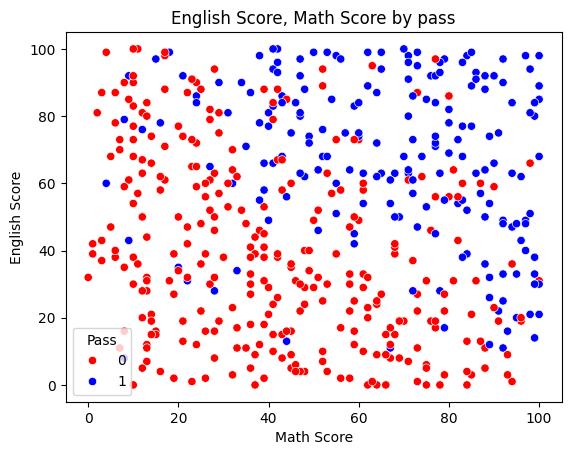

In [84]:
sns.scatterplot(data=Exam_score,
                          x="Math Score",
                          y="English Score",
                          hue="Pass",
                          palette={0:"red", 1:"blue"},
                          )
plt.title("English Score, Math Score by pass")
plt.xlabel("Math Score")
plt.ylabel("English Score")
plt.show()

In [85]:
X = Exam_score[['Math Score', 'English Score']]
y = Exam_score["Pass_Label"]

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

## Titanic.csv

In [88]:
Titanic_train = pd.read_csv("Titanic_train.csv")
Titanic_test = pd.read_csv("Titanic_test.csv")

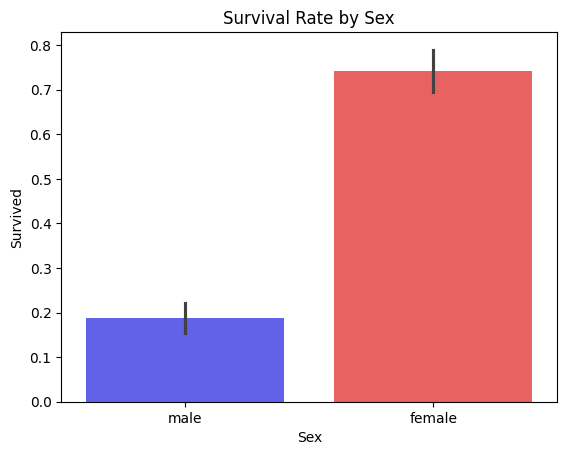

In [89]:
sns.barplot(x="Sex", y="Survived", data=Titanic_train,
                    palette={"male":"blue","female":"red"},
                    alpha=0.7)
plt.title("Survival Rate by Sex")
plt.show()

In [90]:
Titanic_train[Titanic_train["Sex"]=="male"] = 0 # 0: 남자, 1: 여자
Titanic_train[Titanic_train["Sex"]=="female"] = 1
Titanic_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,0,0,0,0,0.0,0,0,0,0.0,0,0
1,1,1,1,1,1,1.0,1,1,1,1.0,1,1
2,1,1,1,1,1,1.0,1,1,1,1.0,1,1
3,1,1,1,1,1,1.0,1,1,1,1.0,1,1
4,0,0,0,0,0,0.0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0.0,0,0,0,0.0,0,0
887,1,1,1,1,1,1.0,1,1,1,1.0,1,1
888,1,1,1,1,1,1.0,1,1,1,1.0,1,1
889,0,0,0,0,0,0.0,0,0,0,0.0,0,0


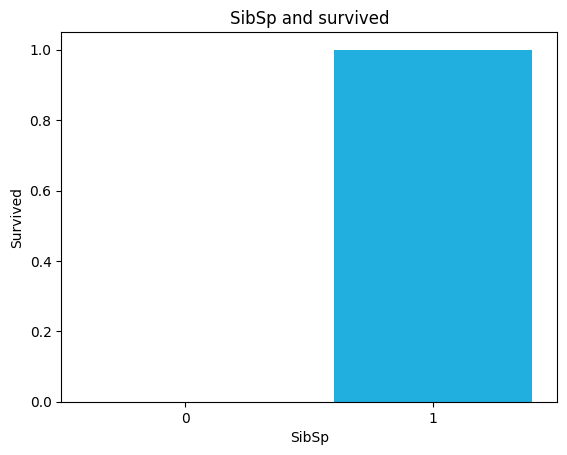

In [91]:
sns.barplot(data=Titanic_train,
                    x="SibSp",
                    y="Survived",
                    color="deepskyblue",
                    )
plt.title("SibSp and survived")
plt.show()

<Axes: xlabel='Pclass', ylabel='Survived'>

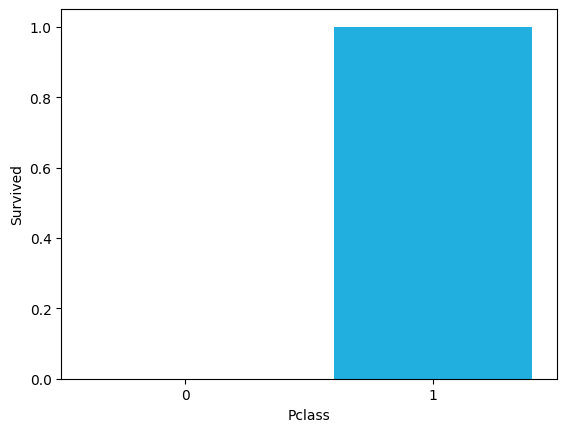

In [92]:
sns.barplot(data=Titanic_train,
                    x="Pclass",
                    y="Survived",
                    color="deepskyblue")   


In [93]:
X_titanic_train = Titanic_train[["Sex","SibSp","Pclass"]]
y_titanic_train = Titanic_train[["Survived"]]

# Logistic Regression

In [94]:
from sklearn.linear_model import LogisticRegression

## Exam Scores

In [95]:
Logistic_exam = LogisticRegression()
Logistic_exam.fit(X_train, y_train)                                      

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [96]:
xx_Exam, yy_Exam = np.meshgrid( #격자생성
    np.linspace(Exam_score["Math Score"].min(), Exam_score["Math Score"].max(), 200), 
    np.linspace(Exam_score["English Score"].min(), Exam_score["English Score"].max(), 200)
)
Exam = np.c_[xx_Exam.ravel(),yy_Exam.ravel()]

z = Logistic_exam.predict_proba(Exam)[:,1]
z = z.reshape(xx_Exam.shape)

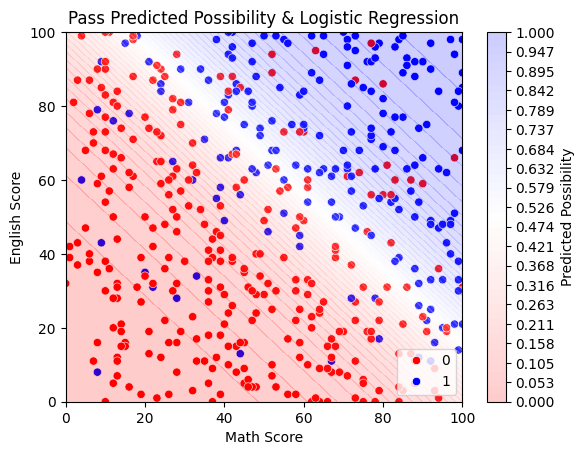

In [97]:
sns.scatterplot(data=Exam_score, 
                          x='Math Score', y='English Score', 
                          hue='Pass', 
                          palette={0:'red', 1:'blue'})
cbar = plt.colorbar(plt.contourf(xx_Exam,yy_Exam,z,  
                                 levels=np.linspace(0, 1, 50), 
                                 alpha=0.2,   
                                 cmap="bwr_r"),)
cbar.set_label("Predicted Possibility", fontsize=10)
cbar.set_ticks(np.linspace(0,1,20))
plt.legend(loc="lower right")
plt.title("Pass Predicted Possibility & Logistic Regression", fontsize=12)
plt.show()

## Titanic

In [98]:
Logistic_Titanic = LogisticRegression()
Logistic_Titanic.fit(X_titanic_train,y_titanic_train)
Logistic_Titanic

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


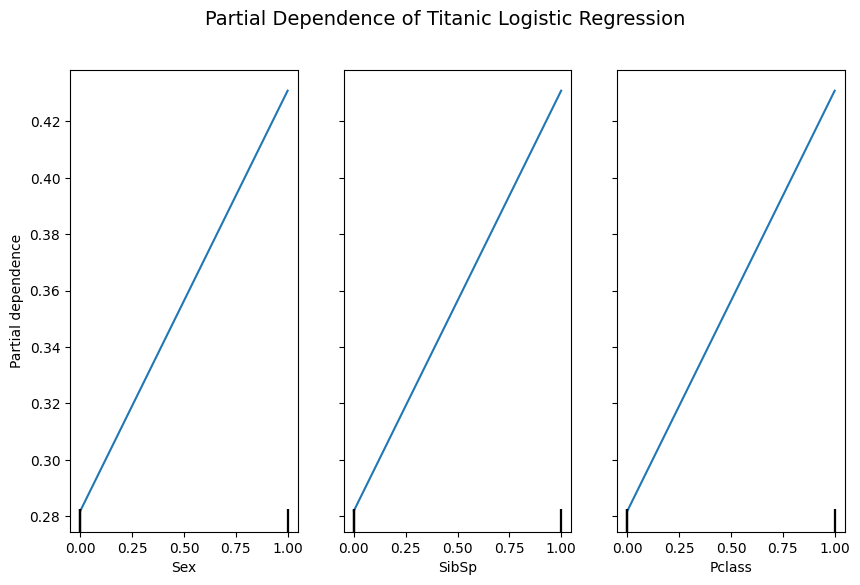

In [101]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    Logistic_Titanic, 
    X_titanic_train, 
    features=[0, 1, 2],   # 0=Sex, 1=SibSp, 2=Pclass
    ax=ax
)
plt.suptitle("Partial Dependence of Titanic Logistic Regression", fontsize=14)
plt.show()